In [1]:
# Cell 1: SETUP AND IMPORTS
import step1_loading
import step2_preprocessing
import step3_epoching
import step4_pseudotrials
import step5_decoding
import step6_visualization
import step7_comparison
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuration
BASIC_PATH = 'project/ds006761'

In [2]:
# Cell 2: HELPER FUNCTIONS FOR NOTEBOOK WORKFLOW
def process_single_subject(subject_id, player_num=1):
    print(f"Processing {subject_id}, Player {player_num}")
    
    # 1. Load data
    raw_p1, raw_p2 = step1_loading.load_and_split_data(subject_id, BASIC_PATH)
    raw_data = raw_p1 if player_num == 1 else raw_p2
    
    if raw_data is None:
        print(f"❌ No data for Player {player_num}")
        return None
    
    # 2. Preprocess - TRY DIFFERENT WAYS
    print(f"   Preprocessing...")
    
    # Method 1: Try new way (4 arguments)
    try:
        raw_clean = step2_preprocessing.run_preprocessing(
            raw_data, 
            subject_id, 
            BASIC_PATH, 
            player_num
        )
        print("   ✅ Used new preprocessing (with bad channel loading)")
        
    except TypeError:
        # Method 2: Try old way (1 argument)
        print("   ⚠️ Falling back to old preprocessing (no bad channels)")
        raw_clean = step2_preprocessing.run_preprocessing(raw_data)
    
    # 3. Epoch
    print("3. Epoching...")
    epochs_tuple, df_clean = step3_epoching.run_epoching(
        raw_clean, subject_id, BASIC_PATH, player_num
    )
    
    # 4. Create pseudo-trials
    print("4. Creating pseudo-trials...")
    epochs_binned = step4_pseudotrials.create_pseudo_trials(epochs_tuple)
    
    # 5. Decode
    print("5. Decoding...")
    labels = df_clean[f'player{player_num}_resp'].values
    
    # Check which decoding function is available
    if hasattr(step5_decoding, 'run_svm_decoding_with_pseudotrials'):
        print("   Using new decoding with pseudo-trials")
        times, scores, std_scores, _ = step5_decoding.run_svm_decoding_with_pseudotrials(
            epochs_binned, labels, n_folds=10, n_average=4, n_repeats=20
        )
    else:
        print("   Using old decoding function")
        times, scores = step5_decoding.run_svm_decoding_original(epochs_binned, custom_labels=labels)
        std_scores = None
    
    # 6. Plot
    print("6. Plotting results...")
    step6_visualization.plot_paper_replication(
        times, scores, f"{subject_id} - Player {player_num}"
    )
    
    return times, scores, epochs_binned, df_clean

def compare_methods(subject_id, player_num=1):
    """
    Compare your SVM method vs. original LDA method
    """
    # Process data once
    raw_p1, raw_p2 = step1_loading.load_and_split_data(subject_id, BASIC_PATH)
    raw_data = raw_p1 if player_num == 1 else raw_p2
    raw_clean = step2_preprocessing.run_preprocessing(raw_data, subject_id, BASIC_PATH)
    epochs_tuple, df_clean = step3_epoching.run_epoching(raw_clean, subject_id, BASIC_PATH, player_num)
    epochs_binned = step4_pseudotrials.create_pseudo_trials(epochs_tuple)
    labels = df_clean[f'player{player_num}_resp'].values
    
    # Run both methods
    print("=== YOUR SVM METHOD ===")
    times_svm, scores_svm, _, _ = step5_decoding.run_svm_decoding_with_pseudotrials(
        epochs_binned, labels
    )
    
    print("\n=== PAPER'S LDA METHOD ===")
    # You'll need to implement LDA function
    # times_lda, scores_lda = step5_decoding.run_lda_decoding_with_pseudotrials(...)
    
    # Plot comparison
    plt.figure(figsize=(12, 6))
    plt.plot(times_svm, scores_svm, label='Your SVM', linewidth=2)
    # plt.plot(times_lda, scores_lda, label='Paper LDA', linewidth=2)
    plt.axhline(33.33, color='r', linestyle='--', label='Chance (33%)')
    plt.title(f"Method Comparison: {subject_id} - Player {player_num}")
    plt.xlabel("Time (s)")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

=== TESTING: sub-03, Player 1 ===
Processing sub-03, Player 1
--- [step1_loading] Reading project/ds006761/sub-03/eeg/sub-03_task-RPS_eeg.bdf ---
   -> Total Channels Detected: 143
   -> Layout detected: STANDARD (Gap between players).
   -> Splitting data into Player 1 and Player 2...
   -> Player 1 Channels: 64
   -> Player 2 Channels: 64
   Preprocessing...

--- [step2_preprocessing] Cleaning Pipeline ---
   Subject: sub-03, Player: 1
   Original First Name: 1-A1
   -> Translating 64 BioSemi names to Standard 10-20 system...
   -> Success! New First Name: Fp1 (Should be Fp1)
   Set bad channels: ['T7', 'P6']
   -> 10-20 System Montage applied.
   Interpolating 2 bad channels...
   -> Applying CAR...
   -> Resampling to 256Hz...

   ✅ Used new preprocessing (with bad channel loading)
3. Epoching...
--- [step3_epoching] Extracting 3 Phases (Dec, Resp, Feed) ---
   Removing 12 trials (first of each block)
   Remaining trials: 468 (was 480)
   Found 466 valid trials after removal
   -> 

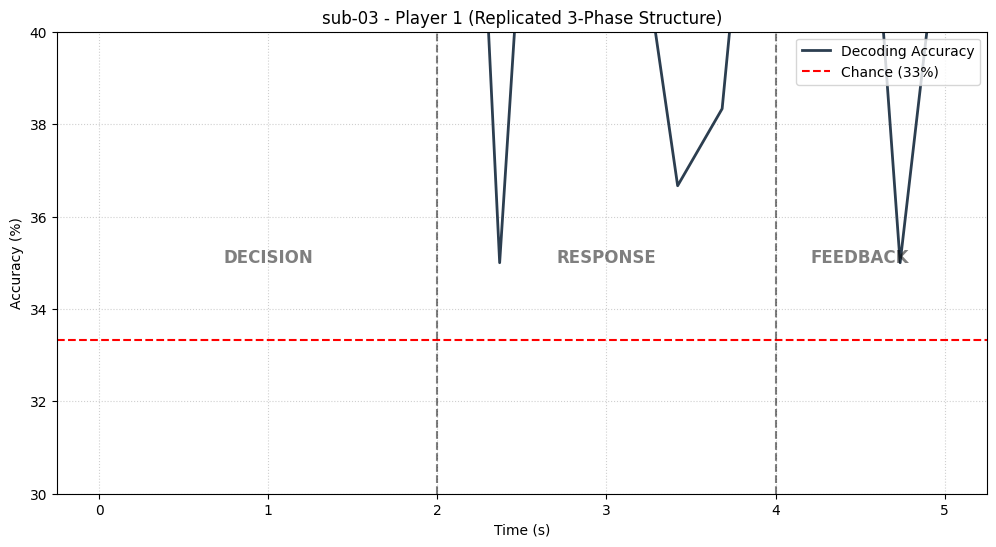


✅ Successfully processed!
   Accuracy range: 35.00% - 70.00%
   Mean accuracy: 51.75%


In [6]:
# Cell 3: TEST SINGLE SUBJECT
# This is your single-subject testing cell

subject_id = 'sub-03'  # Change this to test different subjects
player_num = 1  # Test Player 1

print(f"=== TESTING: {subject_id}, Player {player_num} ===")
results = process_single_subject(subject_id, player_num)

if results is not None:
    times, scores, epochs_binned, df_clean = results
    print(f"\n✅ Successfully processed!")
    print(f"   Accuracy range: {np.min(scores):.2f}% - {np.max(scores):.2f}%")
    print(f"   Mean accuracy: {np.mean(scores):.2f}%")


Processing: sub-01

  Player 1:
--- [step1_loading] Reading project/ds006761/sub-01/eeg/sub-01_task-RPS_eeg.bdf ---
   -> Total Channels Detected: 143
   -> Layout detected: STANDARD (Gap between players).
   -> Splitting data into Player 1 and Player 2...
   -> Player 1 Channels: 64
   -> Player 2 Channels: 64

--- [step2_preprocessing] Cleaning Pipeline ---
   Original First Name: 1-A1
   -> Translating 64 BioSemi names to Standard 10-20 system...
   -> Success! New First Name: Fp1 (Should be Fp1)
   -> 10-20 System Montage applied.
   -> Applying CAR...
   -> Resampling to 256Hz...

--- [step3_epoching] Extracting 3 Phases (Dec, Resp, Feed) ---
   Removing 12 trials (first of each block)
   Remaining trials: 468 (was 480)
   Found 468 valid trials after removal
   -> Epoching Decision Phase (-0.2 to 2.0s)...
   -> Epoching Response Phase (-0.2 to 2.0s)...
   -> Epoching Feedback Phase (-0.2 to 1.0s)...
--- [step4_pseudotrials] Binning and Stitching Phases ---
   -> Binning Decision

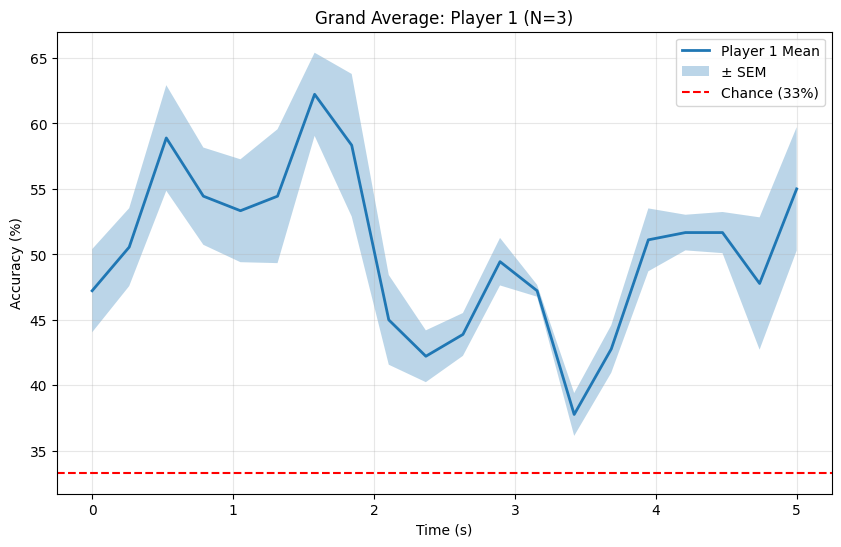

Player 1: Mean accuracy = 50.25%


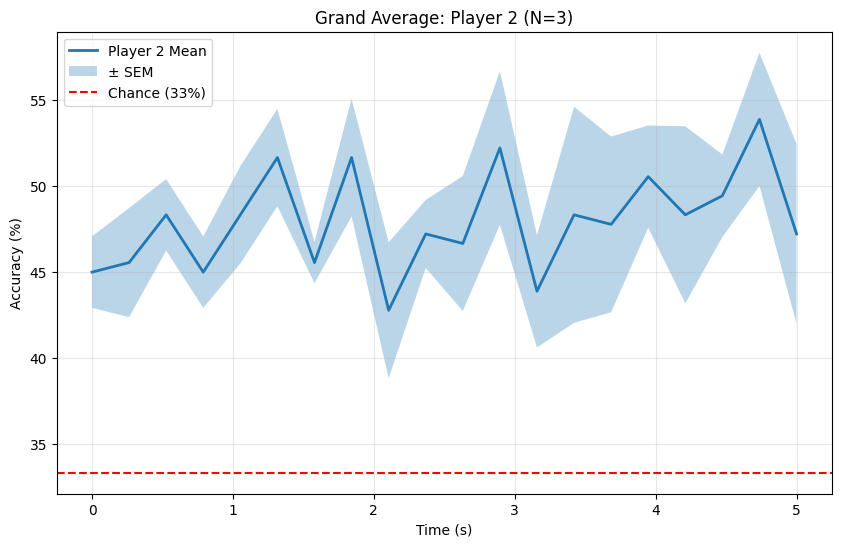

Player 2: Mean accuracy = 47.97%


In [3]:
# Cell 4: MULTI-SUBJECT ANALYSIS
# This is your batch processing cell

subjects_to_process = ['sub-01', 'sub-02', 'sub-03']  # Start with a few
all_results = {1: [], 2: []}  # Store by player

for subject_id in subjects_to_process:
    print(f"\n{'='*50}")
    print(f"Processing: {subject_id}")
    print('='*50)
    
    # Process both players
    for player_num in [1, 2]:
        print(f"\n  Player {player_num}:")
        
        try:
            # Load and preprocess
            raw_p1, raw_p2 = step1_loading.load_and_split_data(subject_id, BASIC_PATH)
            raw_data = raw_p1 if player_num == 1 else raw_p2
            
            if raw_data is None:
                print("    ❌ No data, skipping")
                continue
            
            raw_clean = step2_preprocessing.run_preprocessing(raw_data, subject_id, BASIC_PATH)
            
            # Epoch
            epochs_tuple, df_clean = step3_epoching.run_epoching(
                raw_clean, subject_id, BASIC_PATH, player_num
            )
            
            # Create pseudo-trials
            epochs_binned = step4_pseudotrials.create_pseudo_trials(epochs_tuple)
            
            # Decode
            labels = df_clean[f'player{player_num}_resp'].values
            times, scores, _, _ = step5_decoding.run_svm_decoding_with_pseudotrials(
                epochs_binned, labels
            )
            
            all_results[player_num].append(scores)
            print(f"    ✅ Decoded: {np.mean(scores):.2f}% accuracy")
            
        except Exception as e:
            print(f"    ❌ Error: {e}")
            continue

# After processing all, plot grand average
print("\n" + "="*60)
print("GRAND AVERAGE RESULTS")
print("="*60)

time_axis = np.linspace(0, 5.0, 20)  # 20 bins = 5 seconds

for player_num in [1, 2]:
    if all_results[player_num]:
        scores_matrix = np.array(all_results[player_num])
        mean_scores = np.mean(scores_matrix, axis=0)
        sem_scores = np.std(scores_matrix, axis=0) / np.sqrt(scores_matrix.shape[0])
        
        plt.figure(figsize=(10, 6))
        plt.plot(time_axis, mean_scores, label=f'Player {player_num} Mean', linewidth=2)
        plt.fill_between(time_axis, mean_scores - sem_scores, mean_scores + sem_scores, 
                        alpha=0.3, label='± SEM')
        plt.axhline(33.33, color='r', linestyle='--', label='Chance (33%)')
        plt.title(f"Grand Average: Player {player_num} (N={scores_matrix.shape[0]})")
        plt.xlabel("Time (s)")
        plt.ylabel("Accuracy (%)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        print(f"Player {player_num}: Mean accuracy = {np.mean(mean_scores):.2f}%")

In [3]:
# Cell: EXAMINE PARTICIPANTS.TSV
import pandas as pd
import os

participants_file = f'{BASIC_PATH}/participants.tsv'
if os.path.exists(participants_file):
    participants_df = pd.read_csv(participants_file, sep='\t')
    print("participants.tsv loaded successfully!")
    print(f"Shape: {participants_df.shape}")
    print("\nColumns:")
    print(participants_df.columns.tolist())
    print("\nFirst few rows:")
    print(participants_df.head())
else:
    print(f"File not found: {participants_file}")

participants.tsv loaded successfully!
Shape: (31, 10)

Columns:
['participant_id', 'date', 'player1_age', 'player1_gender', 'player1_handedness', 'player1_pre_processing_channels_fixed', 'player2_age', 'player2_gender', 'player2_handedness', 'player2_pre_processing_channels_fixed']

First few rows:
  participant_id        date  player1_age player1_gender player1_handedness  \
0         sub-01   9/11/2021           25              F                  R   
1         sub-02  16/11/2021           22              F                  R   
2         sub-03  23/11/2021           26              F                  L   
3         sub-04  23/11/2021           32              M                  R   
4         sub-05  24/11/2021           26              F                  R   

  player1_pre_processing_channels_fixed  player2_age player2_gender  \
0                                   NaN           35              M   
1                      FC5, T7, POz, P2           27              F   
2           

In [4]:
# Cell: TEST BAD CHANNEL LOADING SPECIFICALLY

def test_bad_channel_loading(subject_id='sub-01'):
    """
    Test function to verify bad channel loading works
    """
    print(f"Testing bad channel loading for {subject_id}")
    print("="*50)
    
    # Test both players
    for player_num in [1, 2]:
        print(f"\nPlayer {player_num}:")
        
        # Try to load the bad channels
        bad_channels = step2_preprocessing.load_bad_channels_from_participants(
            subject_id, BASIC_PATH, player_num
        )
        
        if bad_channels:
            print(f"  ✅ Found {len(bad_channels)} bad channels: {bad_channels}")
            
            # Check if these channels exist in our standard channel list
            standard_64_names = [
                'Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 
                'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 
                'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 
                'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz',
                'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 
                'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 
                'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 
                'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2', 'Fpz'
            ]
            
            # Check which channels are valid
            valid_channels = [ch for ch in bad_channels if ch in standard_64_names]
            if len(valid_channels) != len(bad_channels):
                print(f"  ⚠️ Warning: Some channels not in standard 64: ")
                print(f"     Bad channels: {bad_channels}")
                print(f"     Valid channels: {valid_channels}")
        else:
            print(f"  ℹ️ No bad channels found or column was empty")
    
    print("\n" + "="*50)
    
# Run test
test_bad_channel_loading('sub-01')
test_bad_channel_loading('sub-02')  # Has bad channels for player1
test_bad_channel_loading('sub-03')  # Has bad channels for player1

Testing bad channel loading for sub-01

Player 1:
   No bad channels specified for sub-01 (NaN)
  ℹ️ No bad channels found or column was empty

Player 2:
   Loaded 1 bad channels from player2_pre_processing_channels_fixed: ['T8']
  ✅ Found 1 bad channels: ['T8']

Testing bad channel loading for sub-02

Player 1:
   Loaded 4 bad channels from player1_pre_processing_channels_fixed: ['FC5', 'T7', 'POz', 'P2']
  ✅ Found 4 bad channels: ['FC5', 'T7', 'POz', 'P2']

Player 2:
   No bad channels specified for sub-02 (NaN)
  ℹ️ No bad channels found or column was empty

Testing bad channel loading for sub-03

Player 1:
   Loaded 2 bad channels from player1_pre_processing_channels_fixed: ['T7', 'P6']
  ✅ Found 2 bad channels: ['T7', 'P6']

Player 2:
   Loaded 1 bad channels from player2_pre_processing_channels_fixed: ['FC1']
  ✅ Found 1 bad channels: ['FC1']

